In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
IMG_SIZE = 32

In [2]:
DATA_DIR = Path("traffic_sign")

TRAIN_CSV = DATA_DIR / "Train.csv"
TEST_CSV = DATA_DIR / "Test.csv"
META_CSV = DATA_DIR / "Meta.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
meta_df = pd.read_csv(META_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Meta shape:", meta_df.shape)

train_df.head()

Train shape: (39209, 8)
Test shape: (12630, 8)
Meta shape: (43, 5)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [3]:
print(train_df.info())
print(train_df.isnull().sum())
print("Numri i klasave:", train_df["ClassId"].nunique())

<class 'pandas.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Width    39209 non-null  int64
 1   Height   39209 non-null  int64
 2   Roi.X1   39209 non-null  int64
 3   Roi.Y1   39209 non-null  int64
 4   Roi.X2   39209 non-null  int64
 5   Roi.Y2   39209 non-null  int64
 6   ClassId  39209 non-null  int64
 7   Path     39209 non-null  str  
dtypes: int64(7), str(1)
memory usage: 2.4 MB
None
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64
Numri i klasave: 43


In [4]:
def load_image(relative_path, img_size=IMG_SIZE):
    image_path = DATA_DIR / relative_path
    image = Image.open(image_path).convert("RGB")
    image = image.resize((img_size, img_size))
    image = np.array(image) / 255.0
    return image

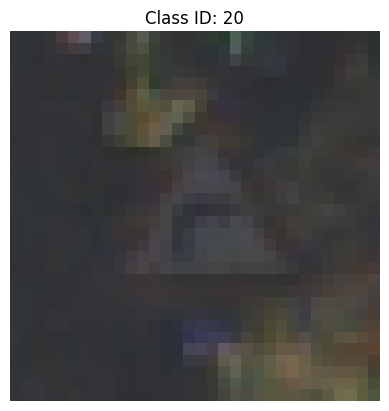

In [5]:
sample_image = load_image(train_df.iloc[0]["Path"])

plt.imshow(sample_image)
plt.title(f"Class ID: {train_df.iloc[0]['ClassId']}")
plt.axis("off")
plt.show()


In [11]:
USE_SUBSET = True
SUBSET_SIZE = 8000

if USE_SUBSET:
    train_work_df = (
        train_df
        .groupby("ClassId", group_keys=True)
        .apply(
            lambda x: x.sample(
                min(len(x), max(1, SUBSET_SIZE // train_df["ClassId"].nunique())),
                random_state=RANDOM_STATE
            )
        )
        .reset_index()
    )
else:
    train_work_df = train_df.copy().reset_index(drop=True)

X_images = np.array([load_image(path) for path in train_work_df["Path"]])
y = train_work_df["ClassId"].values

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_images,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

pca = PCA(n_components=100, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("X_train_img:", X_train_img.shape)
print("X_test_img:", X_test_img.shape)
print("X_train_pca:", X_train_pca.shape)


X_train_img: (6398, 32, 32, 3)
X_test_img: (1600, 32, 32, 3)
X_train_pca: (6398, 100)
